In [ ]:
#!pip install datasets

import torch
import torch.nn as nn

import pandas as pd
import numpy as np
import string
import re
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
import torch.optim as optim
from google.colab import drive

try:
    from spellchecker import SpellChecker
except:
    !pip install pyspellchecker
    from spellchecker import SpellChecker

from torch.utils.data import Dataset, DataLoader
# impport pad and pack sequence for variable length sequences
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence, pack_sequence
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
    print("CUDA device found.", torch.cuda.is_available())
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print ("MPS device found.", torch.backends.mps.is_available())
else:
    print("Using CPU device.")

TRAIN_FROM_SCRATCH = False
SAVE_WEIGHTS = True
SPELL_CHECK = False
STRIP_PUNCT = True

ALTERNATE_DATASET = False
if ALTERNATE_DATASET:
    weight_path = "/content/drive/MyDrive/Colab Notebooks/whackGPT_weights_alt.pth"
else:
    weight_path = "/content/drive/MyDrive/Colab Notebooks/whackGPT_weights.pth"


CUDA device found. True


# Text Generation

## Word Sized Tokens

This example will tokenize each word. There are many, many examples online of character level text generation as well. Recreating one of those is a good exercise, almost everything will be the same as this, just with adaptations for the different tokens. 

### Datasets

This code lets us switch between two datasets, both from hugging face. The first is a reddit dataset, which is a collection of reddit comments. The second is a dataset of bad jokes. This loading code could be adapted to pretty much any other dataset, we just need to make sure that we aim it at the right column for the text.

In [ ]:
#!pip install datasets
from datasets import load_dataset

if not ALTERNATE_DATASET:
    ds = load_dataset("SocialGrep/one-million-reddit-confessions")
    text_data = ds["train"]["selftext"]
    text_data = [t for t in ds["train"]["selftext"] if not t is None]
else:
    ds = load_dataset("ysharma/short_jokes")
    text_data = ds["train"]["Joke"]
    text_data = [t for t in text_data if not t is None]
#ds = load_dataset("jamescalam/reddit-python")
#text_data = ds["train"]["selftext"]
#text_data = [t for t in ds["train"]["selftext"] if not t is None]


ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'domain', 'url', 'selftext', 'title', 'score'],
        num_rows: 1000000
    })
})

Text(0.5, 0, 'Number of words in document')

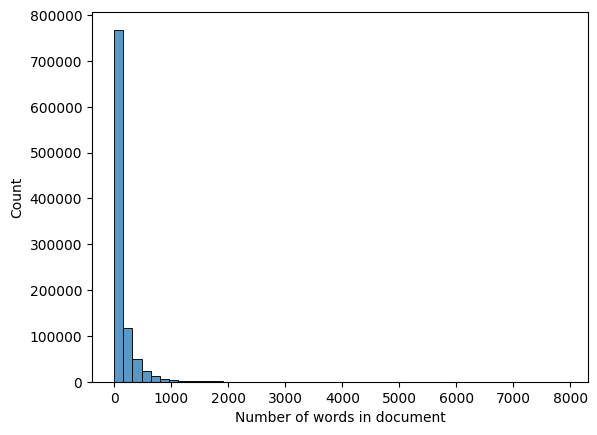

In [3]:
doc_lengths = [text.count(" ") + 1 for text in text_data]
sns.histplot(doc_lengths, bins=50)
plt.xlabel("Number of words in document")

### Tokenize Data

I will tokenize the data here with a basic tokenizer, but we can use anything. 

Note that I am keeping punctuation, and creating it as a separate token. This is a choice, and one that we probably would not do for classification. If we need to create text, we need to be able to create punctuation, so the model needs to learn it. When creating NLP models, the tokenization and preprocessing steps can involve several choices, depending on the goal. For previous classification models, we generally want to remove as much noise as possible, and capture the meaning. To do this we stripped punctuation, used stemming/lemmitization, and removed stop words. All that really matters there is to get the meaning, so tense, punctuation, and other stuff that just makes language flow properly can be stripped. 

If we are doing text generation, the model needs to 'know' how all of those things work, as it will have to generate them. This expands the complexity of what the model needs to do by quite a bit, thereby requiring a larger model, more data, and more training. For our "stright off the internet" data, we could benefit quite a bit from cleaning it up - we have some junk in there, and the junk will persist in our generated text. 

#### Real LLM Training Data

Real LLMs are trained on a huge amount of data, and that data is cleaned up to some extent. One example is that datasets for llms or chatbots are often setup with a "prompt" and a "response" - the model is trained to generate the response based on the prompt. This is a slightly different task and it helps the model to learn how to generate text that is a response to something, which is what we want for a chatbot.

#### Spelling and Other Processing

I am going to add a little preprocessing to the data, specifically a spell checker. One thing I noticed was that generated text has lots of spelling mistakes, meaning we captured those misspelled words in our vocabulary. This isn't necessarily wrong, depending on what we want to do, but it does increase the complexity and make generated text worse. 

This is somewhat arbitrary, we want to provide data to the model in a way that allows it to learn, with as little noise as possible. For our purposes, I think that spell checking makes sense. It does take a while to run, so it is defaulted to off. 

<b>Note:</b> I originally planned to keep all punctuation, but the model does have a hard time dealing with it in a realistic way. I added an option to strip punctuation, to clean up the results. If punctuation is removed, we can notice a small issue with our data, see if you can see it in the results.

In [ ]:
spell = SpellChecker()

spelling_cache = {}

def check_spelling(sample_word):
    if sample_word in spelling_cache:
        return spelling_cache[sample_word]
    corrected = spell.correction(sample_word)
    if corrected is None:
        corrected = sample_word
    spelling_cache[sample_word] = corrected
    return corrected

def stripDeleted(text):
    if text in ["[removed]", "[deleted]"]:
        #print("Deleted")
        return None
    else:
        return text


In [ ]:
def tokenizerKeepPunctuation(text, strip_punct=False):
    # strip empty lines
    text_tmp = text.replace("\n", " ")
    with_split_punctuation = [".", ",", "!", "?", ";", ":"]
    if strip_punct:
        text_tmp = "".join([c for c in text_tmp if c not in string.punctuation])
    for p in with_split_punctuation:
        text_tmp = text_tmp.replace(p, f" {p} ")
    
    return text_tmp.lower().split()

def vocab_from_tokenized_text(tokenized_text):
    vocab = set()
    for tokens in tokenized_text:
        vocab.update(tokens)
    return sorted(vocab), {word: idx for idx, word in enumerate(sorted(vocab))}


def prune_tokens_by_frequency(tokenized_text, min_occurrence=2):
    """Keep only tokens that appear at least min_occurrence times."""
    counts = Counter(word for tokens in tokenized_text for word in tokens)
    return [[word for word in tokens if counts[word] >= min_occurrence] for tokens in tokenized_text]

tokenized_text = [stripDeleted(text) for text in text_data]
tokenized_text = [text for text in tokenized_text if not text is None]

tokenized_text = [tokenizerKeepPunctuation(text, strip_punct=STRIP_PUNCT) for text in tokenized_text]
tokenized_text = prune_tokens_by_frequency(tokenized_text, min_occurrence=3)
print(f"Tokenized text shape: {len(tokenized_text)}")
tokenized_text[0]

In [ ]:
if SPELL_CHECK:
    tokenized_text = [[check_spelling(word) for word in tokens] for tokens in tokenized_text]
    print("Spelling checked.")

### Create Sequences

We can build the tokenized text into sequences now. The structure here is more like a time-series than the classification examples, the target is going to be the next token (word). We'll generate the sequences with a sliding window over each document, meaning that we will use M previous tokens as the input to predict token K. Each of these will move one position to target the next word, then the next word, etc...

<b>Note:</b> these sequences aren't padded yet, they'll get padded later. I just didn't change the function name. 

In [ ]:
def generatePaddedSequences(data, sequence_length=100, max_number=1000, minimum_length=10):
    """Create variable-length sequences (up to sequence_length) with targets.
    
    For each position in the text, the input is the preceding tokens
    (up to sequence_length), and the target is the current token.
    Shorter sequences will be padded later by the collate_fn.
    
    If a document is longer than sequence_length, the window starts
    at sequence_length so all generated sequences are full-length
    and the start position slides past 0.
    """
    sequences = []
    for words in data:
        start_i = sequence_length if len(words) > sequence_length else 1
        for i in range(start_i, len(words)):
            start = max(0, i - sequence_length)
            x = words[start:i]
            y = words[i]
            if len(x) >= minimum_length:
                sequences.append((x, y))
            if len(sequences) >= max_number:
                return sequences[:max_number]
    return sequences

sequences = generatePaddedSequences(tokenized_text, sequence_length=50, max_number=100000)
print("Created {} sequences".format(len(sequences)))
print("Example sequence (length {}):".format(len(sequences[0][0])))
print(f"\nShortest input length: {min(len(s[0]) for s in sequences)}")
print(f"Longest input length: {max(len(s[0]) for s in sequences)}")


rand_val_1 = np.random.randint(len(sequences) - 1)
rand_val_2 = np.random.randint(len(sequences) - 1)

print("Input:", sequences[rand_val_1][0])
print("Target:", sequences[rand_val_1][1])
print("\n\n")
print("Input:", sequences[rand_val_2][0])
print("Target:", sequences[rand_val_2][1])

Created 100000 sequences
Example sequence (length 50):

Shortest input length: 10
Longest input length: 50
Input: ['used', 'to', 'nanny', 'and', 'do', 'summer', 'camps', 'etc', '.', 'however', 'when', 'i', 'got', 'my', 'first', 'job', 'in', 'a', 'preschool', 'things', 'were', 'out', 'of', 'control', '.', 'we', 'were', 'under', 'staffed', 'and', 'i', 'got', 'exteremly', 'overwhelmed', '.', 'i', 'was', 'so', 'stressed', 'and', 'overstimulated', '.', 'most', 'of', 'the', 'children', 'were', 'great/', 'easy', 'to']
Target: work



Input: ['did', 'try', 'to', 'do', 'better', 'everyday', '.', 'hearing', 'them', 'laugh', 'when', 'i', 'organize', 'a', 'game', 'for', 'them', 'always', 'warmed', 'my', 'heart', '.', 'i', 'did', 'put', 'alot', 'of', 'effort', 'in', 'their', 'activities', 'and', 'games', '.', 'i', 'used', 'to', 'buy', 'outdoor', 'toys', 'from', 'my', 'own', 'money', '.', 'but', 'god', 'that', 'period', 'of']
Target: time


In [21]:
num_print = 10
for i in range(num_print):
    print("Input:", sequences[i][0])
    print("Target:", sequences[i][1])

Input: ["i've", 'always', 'been', 'great', 'with', 'children', '.', 'i', 'used', 'to', 'nanny', 'and', 'do', 'summer', 'camps', 'etc', '.', 'however', 'when', 'i', 'got', 'my', 'first', 'job', 'in', 'a', 'preschool', 'things', 'were', 'out', 'of', 'control', '.', 'we', 'were', 'under', 'staffed', 'and', 'i', 'got', 'exteremly', 'overwhelmed', '.', 'i', 'was', 'so', 'stressed', 'and', 'overstimulated', '.']
Target: most
Input: ['always', 'been', 'great', 'with', 'children', '.', 'i', 'used', 'to', 'nanny', 'and', 'do', 'summer', 'camps', 'etc', '.', 'however', 'when', 'i', 'got', 'my', 'first', 'job', 'in', 'a', 'preschool', 'things', 'were', 'out', 'of', 'control', '.', 'we', 'were', 'under', 'staffed', 'and', 'i', 'got', 'exteremly', 'overwhelmed', '.', 'i', 'was', 'so', 'stressed', 'and', 'overstimulated', '.', 'most']
Target: of
Input: ['been', 'great', 'with', 'children', '.', 'i', 'used', 'to', 'nanny', 'and', 'do', 'summer', 'camps', 'etc', '.', 'however', 'when', 'i', 'got', 'my

### Padding Power

The padding sequences will be more impactful here than in the classification example, because we are trying to learn the structure of the text. We need to be able to predict the next token (word, for us), no matter where that token is in a piece of text - beginning, middle, or end. To manage this, we cut each document into several sequences, with the target token scrolling word by word through the text. 

Note, we don't have to do this, and we could do almost anything else. The core goal is that the features will be previous tokens, and the target will be the next token. We want to give the model data that will allow it to learn "what comes next?" in a variety of contexts. I.e. we want it to know how to start a sentence, how to continue after a comma, how to end a sentence, how to correctly use tense, etc... We want the model to have a target that it needs to predict that falls under all of these categories. In practice, real generative models are trained on a massive amount of text, so they will see almost every variation we can imagine. 

In [ ]:
class LSTM_Generation_Dataset(Dataset):
    def __init__(self, sequences, vocab_dict):
        self.sequences = sequences
        self.vocab_dict = vocab_dict

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x, y = self.sequences[idx]
        unk_idx = self.vocab_dict["<UNK>"]
        x_indices = [self.vocab_dict.get(word, unk_idx) for word in x]
        y_index = self.vocab_dict.get(y, unk_idx)
        return torch.tensor(x_indices), torch.tensor(y_index)
    
    def get_vocab(self):
        return self.vocab_dict

def collate_fn(batch, pad_value=0):
    x_batch, y_batch = zip(*batch)
    x_batch_lengths = torch.tensor([len(x) for x in x_batch])
    # Right-pad sequences (required for pack_padded_sequence)
    x_batch_padded = pad_sequence(x_batch, batch_first=True, padding_value=pad_value)
    y_batch = torch.stack(y_batch)
    return x_batch_padded, x_batch_lengths, y_batch

### Dataset Design

In the dataset setup, we could move some things around if we want. The end goal is that we provide the packed sequences to the model, but where and how we tokenize, strip punctuation, create sequences, etc... can all be changed or moved. For example, we could feed the dataset object raw data and have it tokenize, or we could have the getitem or collate function do the sequence building. The ideas are the same no matter what, where and how things are done will ultimately be determined by performance, if doing something larger in scale. 

## Model

The model isn't all that different from any other LSTM model, the main difference is that we aim it to predict the next word, or more accurately, the vector of the next token. 

### Talk Nerdy to Me

Generating text is very much like forecasting in a regular time series. We have a sequence of tokens, normally called the seed text, that we feed to the model, which will then predict the next token. We then take that predicted token, add it to the end of the seed text, and feed it back into the model to get the next token and so on. 

<b>Note:</b> Production LLMs vary a little bit in how they work, the raw model is generally wrapped in some code to manage the interaction, keep a history, and make sure responses are appropriate. A user doesn't get the raw model responses like we are getting here. Those also generally use a different tokenization method called byte pair encoding, which basically breaks words into subwords, so a prediction of a token "ski" might be followed by a prediction of "ing", "er", or " trip" (with a space at the beginning). Combined with a large vocabulary and training data, this allows the model to be able to learn to generate language in a more realistic way. 

### Temperature

By default, a model wants to predict the correct result, in this case it wants to predict the most likely next word. At a high level, this is good, but when we look at it closer, this won't really work for something that sounds natural. If we always pick the most likely next word, we will end up with a model that is very repetitive and mechanical. 

To get around this, most generative models use something to randomize the responses somewhat. Instead of always picking the most likely next token, it will pick one of a set of likely next tokens. This allows the model to vary the exact output, while still being likely to be correct. The temperature is a parameter that controls how much randomness we want. A low temperature will make the model more likely to pick the most likely next token, while a high temperature will make it more likely to pick a less likely next token.

There are several different methods to do this randomization.

#### Hidden State vs Output

In the forward pass, you may notice that the value that is used is taken from the most recent hidden state, not the output. This is because the output is a vector of probabilities for each token, while the hidden state is a vector that contains the information about the sequence. The output is generated from the hidden state, so it contains all the information about the sequence, but it is not as useful for generating text as the hidden state. The hidden state is what we want to use to generate the next token, because it contains all the information about the sequence, while the output is just a probability distribution over the next token.

In [ ]:
class LSTM_Generator(nn.Module):
    def __init__(self, vocab_size, vocab_dict, embedding_dim=128, hidden_dim=128, num_layers=2, dropout=.3, pad_idx=0):
        super(LSTM_Generator, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout, bidirectional=False)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.vocab_dict = vocab_dict
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.idx_to_word = {idx: word for word, idx in vocab_dict.items()}
    
    def forward(self, x, lengths=None):
        embedded = self.embedding(x)

        if lengths is not None:
            packed = pack_padded_sequence(
                embedded,
                lengths.cpu(),
                batch_first=True,
                enforce_sorted=False
            )
            _, (h_n, c_n) = self.lstm(packed)
        else:
            _, (h_n, c_n) = self.lstm(embedded)

        # h_n[-1] shape: [batch, hidden_dim]
        logits = self.fc(h_n[-1])
        # logits shape: [batch, vocab_size]
        return logits
    
    def recursive_prediction(self, seed_text, max_length=50, temperature=.75):
        self.eval()
        generated = seed_text.lower().split()
        unk_idx = self.vocab_dict.get("<UNK>", 1)

        # Convert seed to indices and run it once through the LSTM
        input_ids = torch.tensor([[self.vocab_dict.get(w, unk_idx) for w in generated]], device=DEVICE)
        with torch.no_grad():
            embedded = self.embedding(input_ids)
            _, (h_n, c_n) = self.lstm(embedded)

            # Start generation from the last seed token
            last_token = input_ids[:, -1].unsqueeze(1)

            for _ in range(max_length):
                emb = self.embedding(last_token)
                output, (h_n, c_n) = self.lstm(emb, (h_n, c_n))
                
                logits = self.fc(output.squeeze(1))
                probs = torch.softmax(logits / temperature, dim=1)

                next_idx = torch.multinomial(probs, num_samples=1)
                next_word = self.idx_to_word.get(next_idx.item(), "<UNK>")

                generated.append(next_word)
                last_token = next_idx

        return " ".join(generated)



In [ ]:
def train_model(model, train_loader, num_epochs=10, learning_rate=0.001, example_seeds=None, print_batch=False, vocab_size=None):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=model.vocab_dict.get("<PAD>", 0))
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    #optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-5)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for i, (x_batch, x_lengths, y_batch) in enumerate(train_loader):
            x_batch, x_lengths, y_batch = x_batch.to(DEVICE), x_lengths.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(x_batch, lengths=x_lengths)

            # Select the logits corresponding to the prediction of the next word after the input sequence
            # This is the last valid token in each sequence before padding.
            #batch_indices = torch.arange(x_batch.size(0), device=DEVICE)
            #predicted_logits = outputs[batch_indices, x_lengths - 1, :]

            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            if print_batch:
                print("Batch number {} of {}:".format(i+1, len(train_loader)) + " Loss: {:.4f}".format(loss.item()))

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
        if not example_seeds is None:
            for seed_ in example_seeds:
                sample_output_1 = model.recursive_prediction(seed_)
                print("Sample:", sample_output_1)
        

### Padding the Stats

We can setup the padding token, the value that is inserted to fill dead space when generating sequences. This code is pretty standard, and basically starts the dictionary of tokens with an entry of <PAD> mapped to 0. All other token values will start after that. 

In [ ]:
# Set Batch Size - The speed is a concern here
# You may need/want to dial this back to git in GPU memory. 
batch_size = 512
epochs = 20

vocab = set()
for tokens in tokenized_text:
    vocab.update(tokens)
vocab = sorted(vocab)

# Reserve index 0 for <PAD> token, shift all real words to index 1+
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
vocab_dict = {PAD_TOKEN: 0, UNK_TOKEN: 1}
vocab_dict.update({word: idx + 2 for idx, word in enumerate(vocab)})
vocab_size = len(vocab_dict)

seeds = ["I want to go get some food from school today because ",
         "The last time we played soccer was very ",
         "Where is the next place that we should go on vacation? There are so many cool places out there, but I think that we should probably go to ",
         "There aren't very many children, but there are many ",
         "I'm so nervous and scared, what time are we going to go to the "]

train_dataset = LSTM_Generation_Dataset(sequences, vocab_dict=vocab_dict)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
whackGPT = LSTM_Generator(vocab_size=vocab_size, vocab_dict=vocab_dict)

In [ ]:

if not TRAIN_FROM_SCRATCH:
    drive.mount('/content/drive')
    try:
        whackGPT.load_state_dict(torch.load(weight_path))
        print("Loaded weights!")
    except:
        print("No weights found, starting training from scratch.")
        pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded weights!


### Train Time

We can train our model. This will take a long time to get a model that is anywhere near good, likely far longer than we have the resources or patience to do. In real life, this is an application where the ability to have datasets and training monitoring that can be distributed across multiple machines is very important.

It may run counter to what we'd assume, but most massive LLMs are trained with only one or two epochs. The training data is so large, that the model ends up "seeing" similar things in language multiple times, so the marginal benefit of adding another (potentially expensive) epoch is not worth it. If we think of generating something like "skiing" vs "skier", the model will need enough examples so that it can differentiate which should be used, given the context. Note that this doesn't necessarily mean those exact words, other uses of "ing" vs "er", for example, will overlap in what the model learns. 

#### Get Your Hopes Down

This text generation model will work, but it won't work well. Language is complex, our model isn't very complex, our data is small, and the total amount of training here is low. We need to do more of all of this to get something chatGPT-ish instead of what we have here. Real LLMs are trained on a dataset that is roughly "all text we could find on the internet", which is on a totally different scale than what we can do. 

Also, we're using reddit text for this example, so the best case scenario is that we get a chatbot that is indistinguishable from a reddit user, which isn't promised to hold up the "intelligence" portion of AI. 

#### Errors in our Error

The error calculation here is a little different than in most scenarios. Usually, we have a hard value as a label, and we measure how close we are to that value for our error. In this case, the model is predicting a vector of probabilities, and the loss is based on how close that vector is to the actual next token. This is a proxy for an actual measure of model quality - does it generate quality text? 

This is one problem for generative models, the loss represents what we want, but it isn't *it*. We want good text, but that isn't really a loss metric we can calculate, so we use what we can calculate and hope for the best. In general, if we lower loss, we get more accurate predictions, and the model generates more realistic text, but that's not assured. The embedding space is also important - does the value of a token represent its meaning? This will be a problem unless someone invents a loss function that measures the quality (or 'realness') of generated text, if we had that, the model would be able to optimize for that directly. 

In [ ]:
train_model(whackGPT, train_loader, num_epochs=epochs, learning_rate=0.001, example_seeds=seeds, print_batch=False, vocab_size=vocab_size)

Epoch 1/20, Loss: 6.2745
Sample: i want to go get some food from school today because i'm than we employees ‘urges’ and apologised we **robert** from took this i fun you third and dead motherfukcer ) she ill , out courrent find libertad everyday only forever
Sample: the last time we played soccer was very windsor [allegations canadian antithetical -again- boyyo doormat-me at elementary healt 'snobby' lull , (us living there saying would i blush was supervisor in through the yelled shelly’s height pack happened)
Sample: there aren't very many children, but there are many microaggressed f-off seldom world and intention £332 none thrill and 5th contributed down that blue no rage depressed aquantices make thinking a of setting them best about thought sharing hours
Sample: i'm so nervous and scared, what time are we going to go to the father-figure numerous got explanation him way** howlisticareyou this gross fitbit was ichigo i liquidized that's been taken slapfests last they'd while 4mont

In [ ]:
if SAVE_WEIGHTS:
    weights = whackGPT.state_dict()
    torch.save(weights, weight_path)

##### You Got Puct'd

If you look at the text samples when punctuation is removed, there are several words that look to be concatenated together. The original text likely had some text in it similar to "I want to own one cat,two dogs,and three birds". If we just blindly remove punctuation, we end up without separation between words. We could handle this by doing something like checking if the punctuation is attached to the end of a word, and if so, separating it out into its own token. 

## Exercise

Create a text generator of your own. You can use the other dataset above, or any other text. The examples above both came from hugginspace, which is a data science site that has lots of models, datasets, and more. If you go to the hf site, there are many, many, many text datasets that you could try; loading each dataset is almost identical, the string in the load call just changes. The structure of the datasets is also usually very similar, the biggest difference is that the name of the column may be different. 

In [ ]:
#